# PREDICT 1: Diet–Microbiome Association Explorer

**Source:** Asnicar et al., *"Microbiome connections with host metabolism and habitual diet from 1,098 deeply phenotyped individuals"*, Nature Medicine (2021)  
**DOI:** [10.1038/s41591-020-01183-8](https://doi.org/10.1038/s41591-020-01183-8)

This notebook explores the supplementary data from the PREDICT 1 study — specifically the Spearman correlations between **20 food groups** and **176 named gut microbial species** from 1,098 people. These are real, peer-reviewed, statistically tested diet–microbiome associations from deep metagenomic sequencing.

The goal is to understand which foods associate with which microbes, and to evaluate whether this data can ground the 86BB installation's food→microbiome simulation in real science.

---

### What's in the data

**Supplementary Table 5** contains partial Spearman correlations (adjusted for age and BMI) between dietary variables and species-level relative abundances. It has five sheets:

| Sheet | Variables | What it measures |
|---|---|---|
| Food_groups | 20 food groups | How food categories associate with each species |
| Nutrients_%E | 43 energy-adjusted nutrients | How nutrient intake associates with each species |
| Dietary_patterns | 13 dietary indices | How overall diet quality associates with each species |
| Fasting | 75 blood markers | How each species associates with fasting cardiometabolic markers |
| Post-prandial | 169 blood markers | How each species associates with post-meal metabolic responses |

In [1]:
import zipfile
import xml.etree.ElementTree as ET
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

plt.style.use('dark_background')
sns.set_palette('Set2')
plt.rcParams.update({
    'figure.figsize': (14, 8),
    'figure.dpi': 120,
    'font.size': 10,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
})

## 1. Load the Data

The XLSX files use a strict OOXML namespace that `openpyxl` can't parse, so we extract directly from the underlying XML.

In [2]:
SUPP_DIR = Path('../data/predict1_paper/supplementary')
TABLE5_FILE = SUPP_DIR / '41591_2020_1183_MOESM6_ESM.xlsx'
TABLE9_FILE = SUPP_DIR / '41591_2020_1183_MOESM10_ESM.xlsx'
NS = {'main': 'http://purl.oclc.org/ooxml/spreadsheetml/main'}

def load_strict_xlsx(filepath, sheet_index=0):
    """Parse an OOXML-strict xlsx that openpyxl can't handle."""
    with zipfile.ZipFile(filepath) as z:
        ss_xml = z.read('xl/sharedStrings.xml').decode('utf-8')
        ss_root = ET.fromstring(ss_xml)
        strings = []
        for si in ss_root.findall('.//main:si', NS):
            parts = [t.text for t in si.findall('.//main:t', NS) if t.text]
            strings.append(''.join(parts))

        sheet_file = f'xl/worksheets/sheet{sheet_index + 1}.xml'
        xml = z.read(sheet_file).decode('utf-8')
        root = ET.fromstring(xml)

        rows = []
        for row_el in root.findall('.//main:row', NS):
            cells = {}
            for cell in row_el.findall('main:c', NS):
                ref = cell.attrib.get('r', '')
                col = ''.join(c for c in ref if c.isalpha())
                val_el = cell.find('main:v', NS)
                if val_el is None:
                    continue
                cell_type = cell.attrib.get('t', '')
                if cell_type == 's':
                    cells[col] = strings[int(val_el.text)]
                else:
                    try:
                        cells[col] = float(val_el.text)
                    except ValueError:
                        cells[col] = val_el.text
            if cells:
                rows.append(cells)
        return rows

def rows_to_df(rows, skip_header=3):
    """Convert parsed rows to a DataFrame."""
    data = rows[skip_header:]
    df = pd.DataFrame(data)
    df.columns = ['variable', 'species', 'spearman_r', 'pvalue', 'qvalue']
    df['spearman_r'] = pd.to_numeric(df['spearman_r'], errors='coerce')
    df['pvalue'] = pd.to_numeric(df['pvalue'], errors='coerce')
    df['qvalue'] = pd.to_numeric(df['qvalue'], errors='coerce')
    return df.dropna(subset=['spearman_r'])

food_df = rows_to_df(load_strict_xlsx(TABLE5_FILE, 0))
nutrient_df = rows_to_df(load_strict_xlsx(TABLE5_FILE, 1))
pattern_df = rows_to_df(load_strict_xlsx(TABLE5_FILE, 2))

print(f'Food groups:     {food_df.shape[0]:,} rows  ({food_df.variable.nunique()} groups × {food_df.species.nunique()} species)')
print(f'Nutrients:       {nutrient_df.shape[0]:,} rows  ({nutrient_df.variable.nunique()} nutrients × {nutrient_df.species.nunique()} species)')
print(f'Diet patterns:   {pattern_df.shape[0]:,} rows  ({pattern_df.variable.nunique()} patterns × {pattern_df.species.nunique()} species)')

Food groups:     3,520 rows  (20 groups × 176 species)
Nutrients:       7,568 rows  (43 nutrients × 176 species)
Diet patterns:   2,288 rows  (13 patterns × 176 species)


## 2. Food Group → Species Heatmap

This is the core data: how 20 food groups correlate with 176 gut microbial species. Each cell is a partial Spearman correlation (adjusted for age and BMI). Positive = eating more of that food group is associated with higher abundance of that species.

In [3]:
food_matrix = food_df.pivot(index='species', columns='variable', values='spearman_r')
food_q_matrix = food_df.pivot(index='species', columns='variable', values='qvalue')

print(f'Matrix shape: {food_matrix.shape}')
print(f'Significant associations (FDR < 0.2): {(food_q_matrix < 0.2).sum().sum()}')
print(f'Significant associations (FDR < 0.05): {(food_q_matrix < 0.05).sum().sum()}')
food_matrix.head()

Matrix shape: (176, 20)
Significant associations (FDR < 0.2): 440
Significant associations (FDR < 0.05): 142


variable,Alcohol,Animal_fats,Dairy,Egg,Fish_seafood,Fruit_juices,Fruits,Legumes,Margarine,Meat,Misc_animal_foods,Nuts,Potatoes,Refined_grains,Sugar_sweetened_beverages,Sweets_desserts,Tea_coffee,Vegetable_oils,Vegetables,Whole_grain
species,,,,,,,,,,,,,,,,,,,,
Actinomyces_odontolyticus,-0.074588,-0.062814,0.006612,-0.003623,0.031185,-0.068865,-0.019896,-0.011775,0.013289,-0.037667,-0.021488,-0.069033,-0.004468,-0.035532,0.036955,-0.033160,-0.013187,-0.031350,-0.021325,-0.032057
Actinomyces_sp_ICM47,0.000324,-0.036188,-0.039688,0.031718,-0.002440,-0.032543,-0.042659,0.014215,-0.057457,-0.000241,-0.006618,-0.027299,0.006391,-0.022520,0.028424,-0.039373,0.036867,-0.024897,-0.006546,-0.023807
Adlercreutzia_equolifaciens,0.072010,-0.048440,-0.009758,-0.006135,-0.013057,-0.008905,-0.014502,-0.095705,0.006239,0.075917,-0.049489,0.010389,0.018473,-0.005908,0.000015,0.008705,0.087596,0.013691,0.014116,0.013817
Agathobaculum_butyriciproducens,0.066402,-0.034260,-0.015214,0.074389,0.055757,0.060287,0.057106,0.092315,-0.045555,-0.079312,-0.053967,0.206795,-0.065548,-0.046057,-0.097015,-0.076668,0.137091,0.076442,0.100272,0.051168
Akkermansia_muciniphila,0.034544,0.045359,0.034174,0.041195,-0.003002,0.002996,-0.035255,0.004135,0.013943,0.038043,0.080442,-0.039159,-0.017606,-0.014810,0.050510,0.085258,-0.005910,-0.023164,-0.022249,0.034568


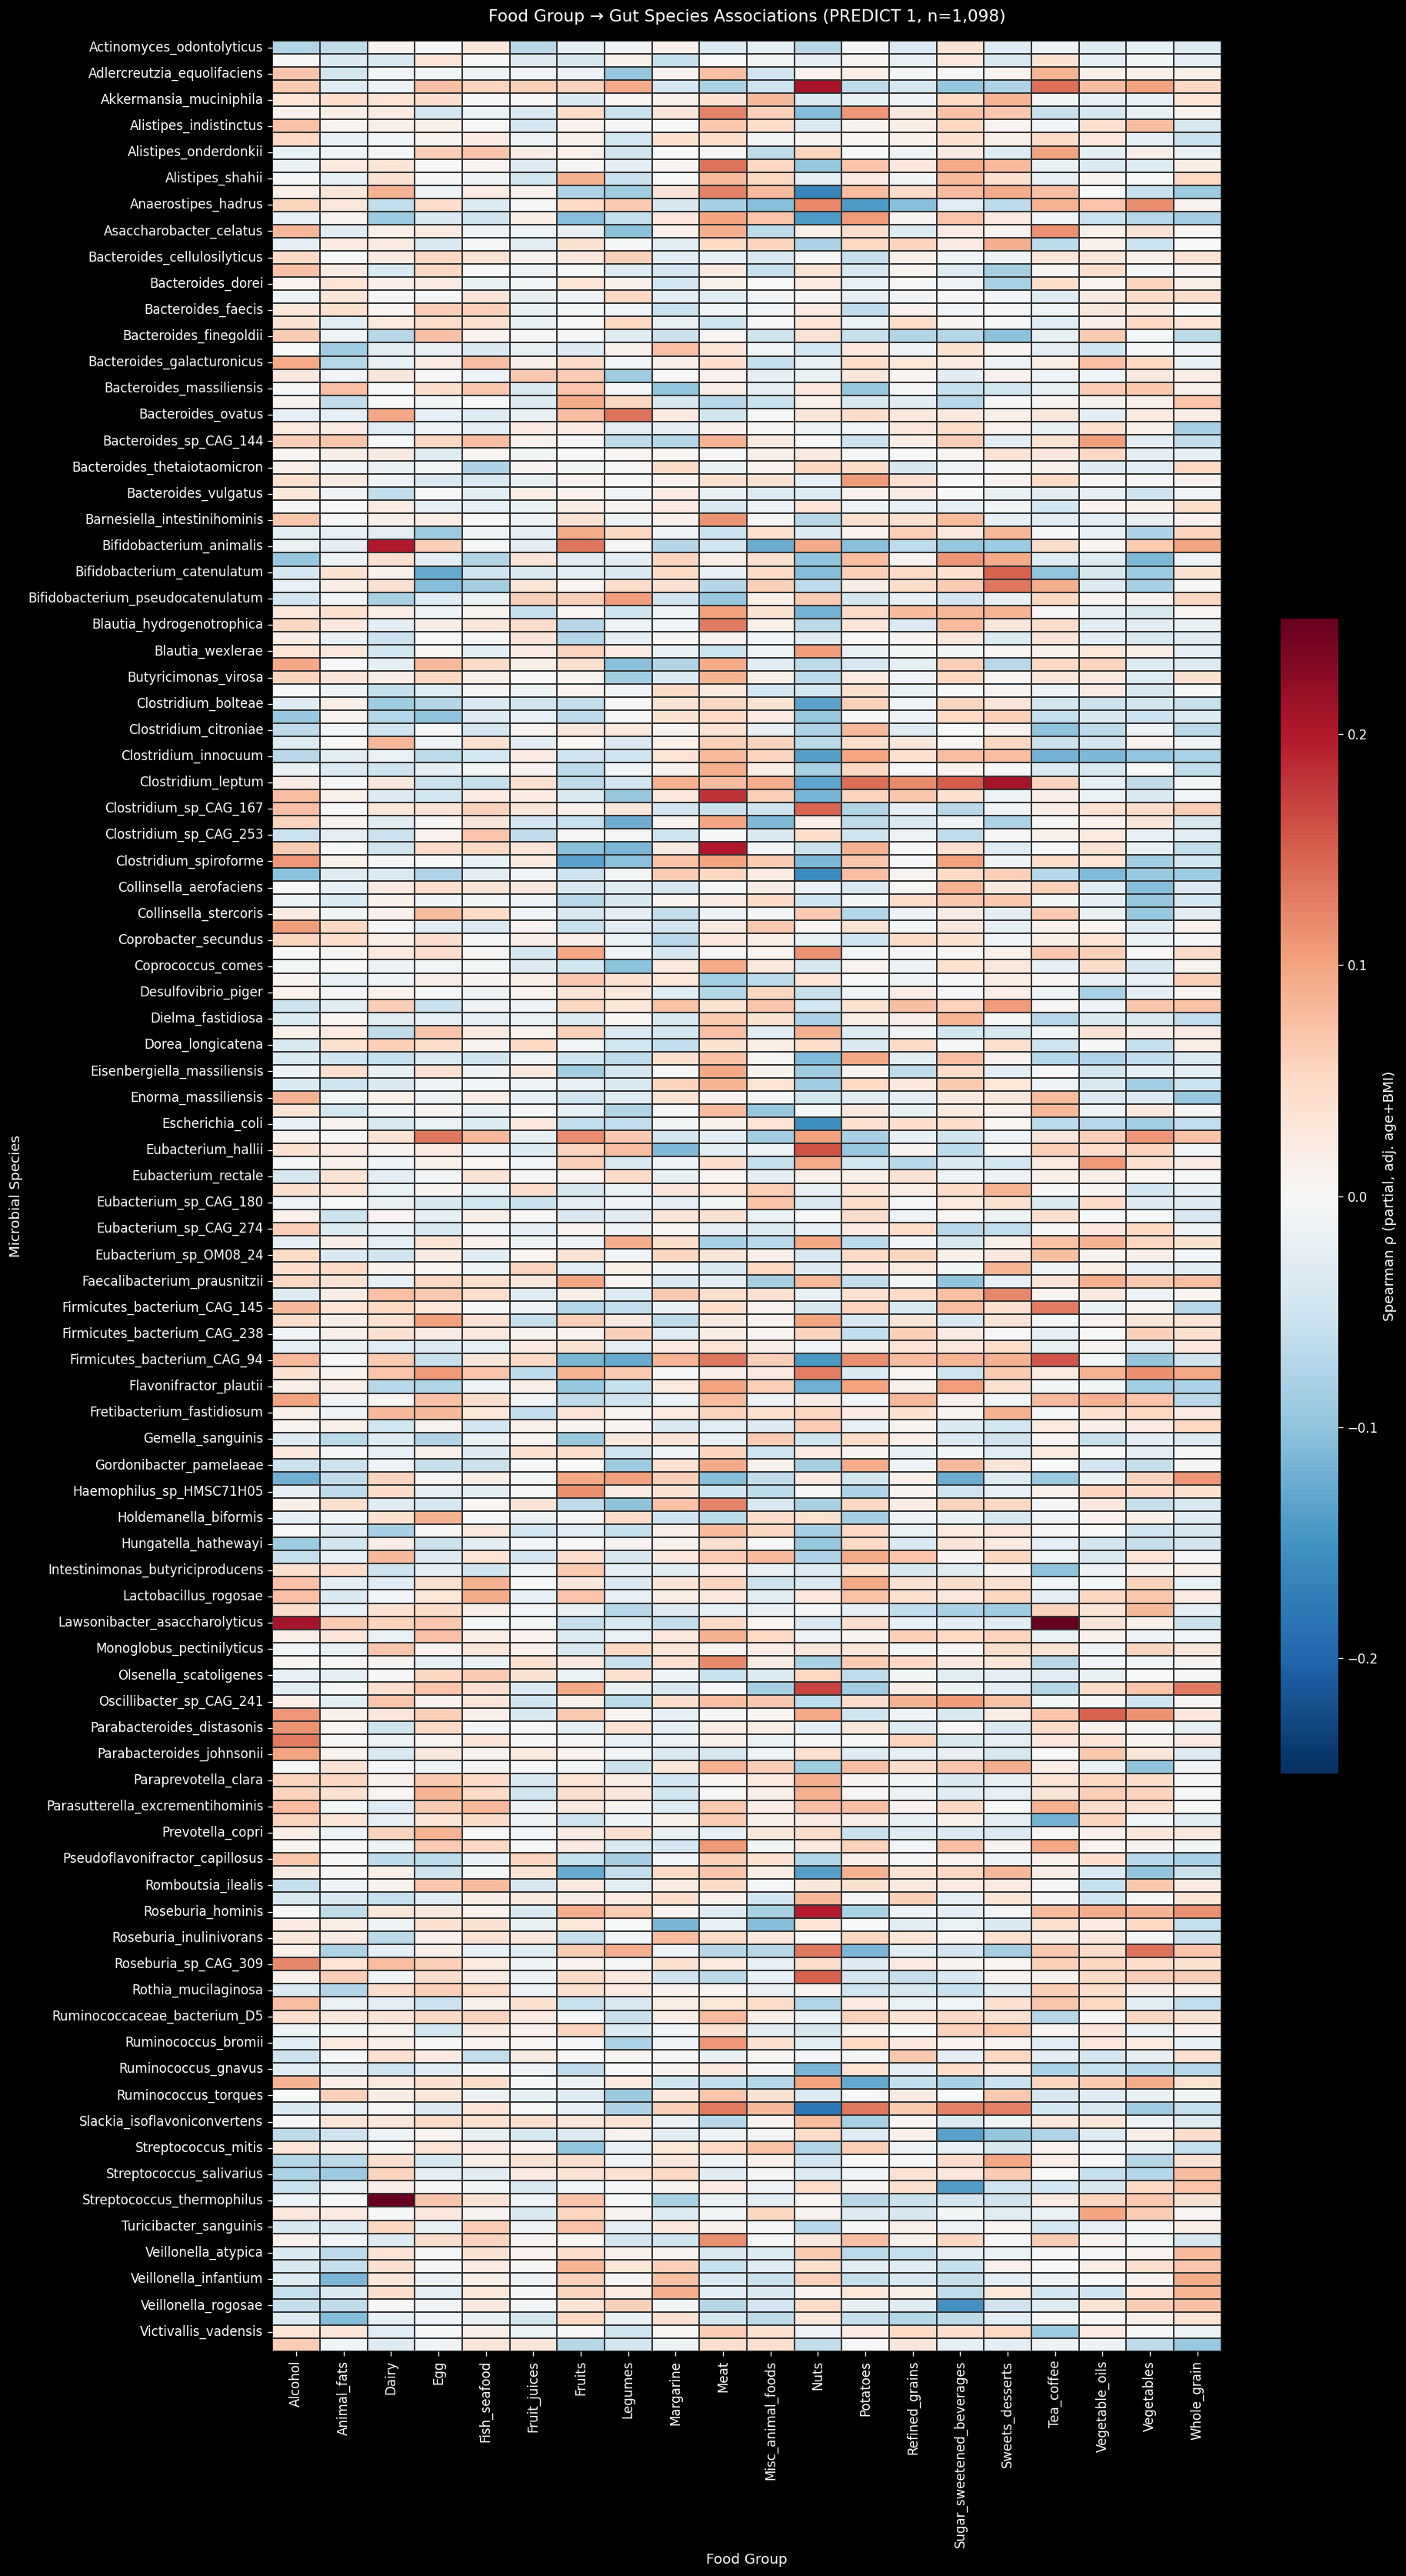

In [4]:
fig, ax = plt.subplots(figsize=(16, 28))
sns.heatmap(
    food_matrix,
    cmap='RdBu_r', center=0, vmin=-0.25, vmax=0.25,
    linewidths=0.1, linecolor='#333333',
    cbar_kws={'label': 'Spearman ρ (partial, adj. age+BMI)', 'shrink': 0.5},
    ax=ax
)
ax.set_title('Food Group → Gut Species Associations (PREDICT 1, n=1,098)', pad=15)
ax.set_xlabel('Food Group')
ax.set_ylabel('Microbial Species')
plt.tight_layout()
plt.show()

## 3. Top Associations by Food Group

For each food group, which species are most strongly associated (positively and negatively)?

In [5]:
sig = food_df[food_df['qvalue'] < 0.2].copy()
sig['abs_r'] = sig['spearman_r'].abs()
sig = sig.sort_values('abs_r', ascending=False)

top_per_group = sig.groupby('variable').head(5)
top_per_group = top_per_group.sort_values(['variable', 'spearman_r'], ascending=[True, False])

display_cols = ['variable', 'species', 'spearman_r', 'qvalue']
top_per_group[display_cols].rename(columns={
    'variable': 'Food Group',
    'species': 'Species',
    'spearman_r': 'Spearman ρ',
    'qvalue': 'FDR q'
})

,Food Group,Species,Spearman ρ,FDR q
121,Alcohol,Lawsonibacter_asaccharolyticus,0.207072,3.862047e-07
130,Alcohol,Parabacteroides_goldsteinii,0.130778,4.270916e-03
147,Alcohol,Roseburia_sp_CAG_309,0.122210,9.477599e-03
129,Alcohol,Parabacteroides_distasonis,0.111779,2.259780e-02
110,Alcohol,Haemophilus_parainfluenzae,-0.120981,1.056661e-02
...,...,...,...,...
3470,Whole_grain,Oscillibacter_sp_57_20,0.130736,4.288925e-03
3487,Whole_grain,Roseburia_hominis,0.114396,1.839465e-02
3454,Whole_grain,Haemophilus_parainfluenzae,0.110583,2.491888e-02
3383,Whole_grain,Bifidobacterium_animalis,0.101372,4.781272e-02


## 4. Species Clustered by Dietary Profile

The paper found that species cluster into two groups: those associated with **healthy plant-based foods** (butyrate producers like *Roseburia*, *Faecalibacterium*) and those associated with **less healthy/processed foods** (*Clostridium*, *Flavonifractor*). Let's see this clustering emerge from the data.

Species with ≥5 significant food group associations: 30


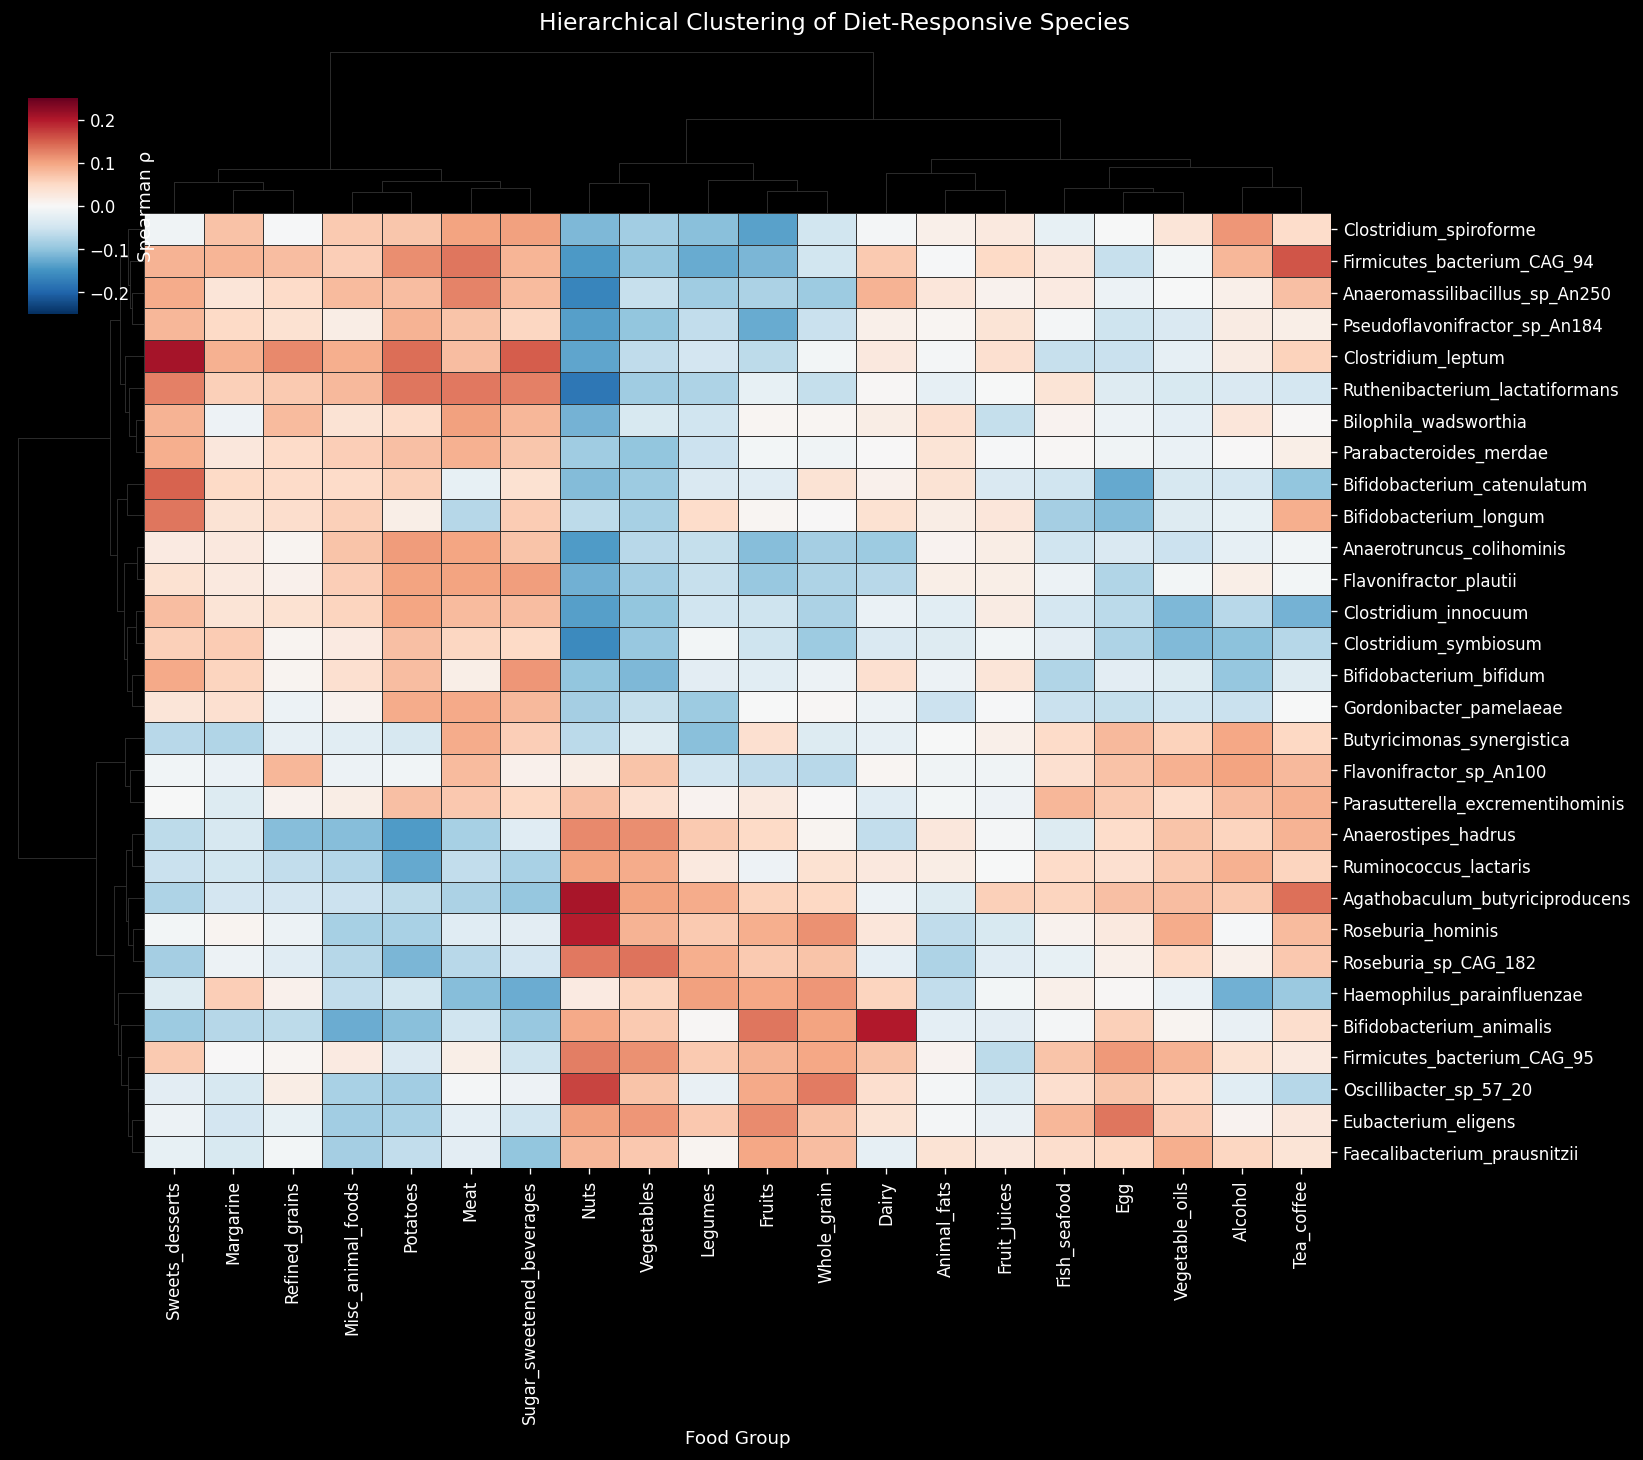

In [6]:
n_sig = (food_q_matrix < 0.2).sum(axis=1)
top_species = n_sig[n_sig >= 5].index.tolist()
print(f'Species with ≥5 significant food group associations: {len(top_species)}')

subset = food_matrix.loc[top_species]

g = sns.clustermap(
    subset,
    cmap='RdBu_r', center=0, vmin=-0.25, vmax=0.25,
    linewidths=0.3, linecolor='#333333',
    figsize=(14, max(10, len(top_species) * 0.4)),
    dendrogram_ratio=(0.1, 0.15),
    cbar_pos=(0.02, 0.8, 0.03, 0.15),
    cbar_kws={'label': 'Spearman ρ'},
    method='ward',
)
g.ax_heatmap.set_xlabel('Food Group')
g.ax_heatmap.set_ylabel('')
g.fig.suptitle('Hierarchical Clustering of Diet-Responsive Species', y=1.01, fontsize=14)
plt.show()

## 5. Strongest Individual Associations

The headline findings from the paper, confirmed in our data extract.

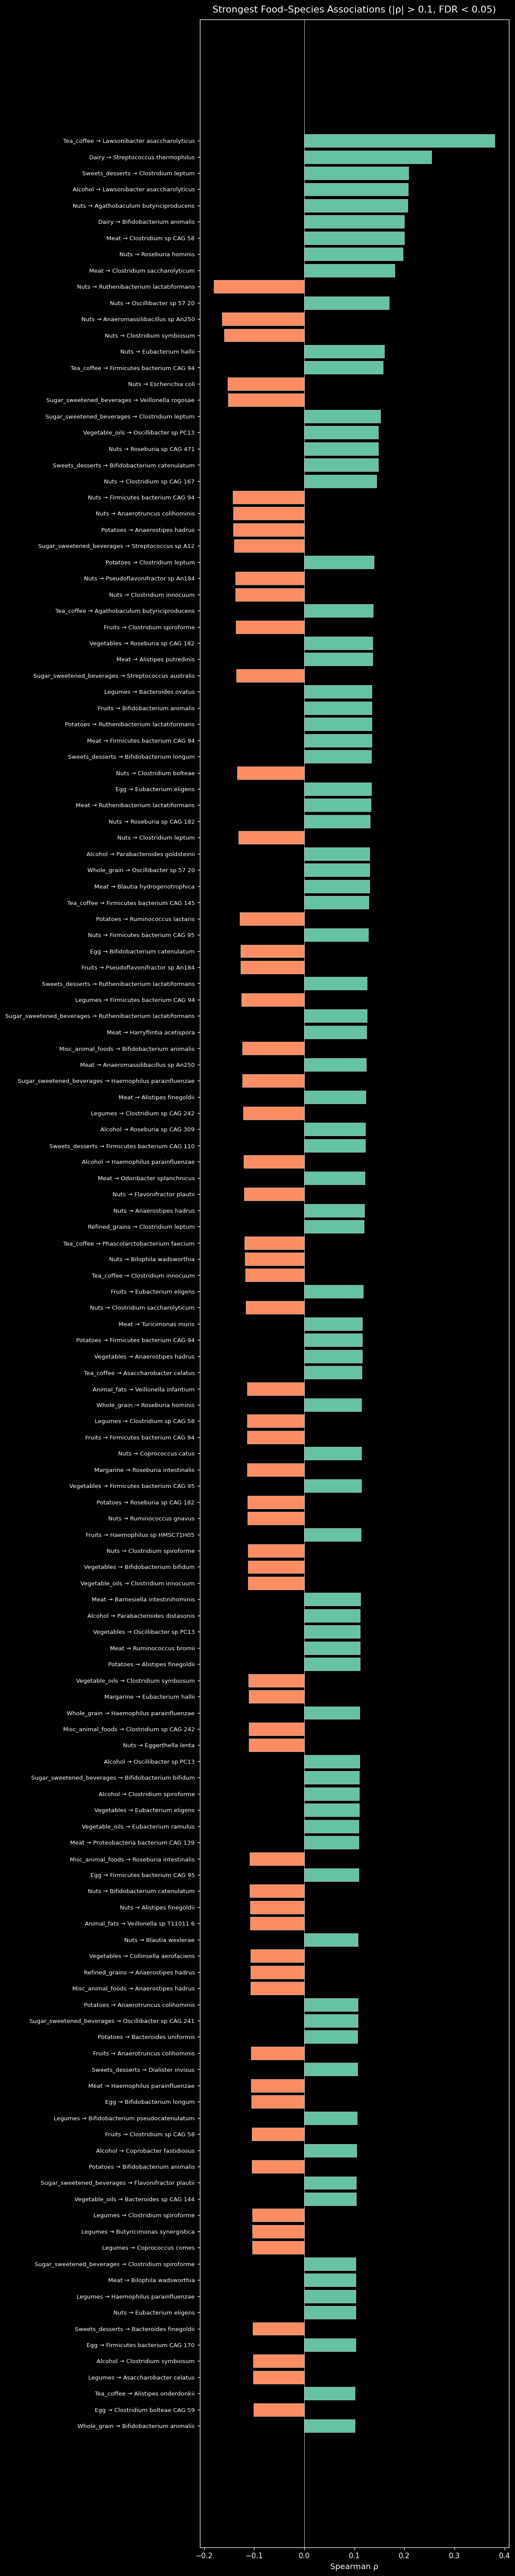

In [7]:
strong = food_df[(food_df['qvalue'] < 0.05) & (food_df['spearman_r'].abs() > 0.1)].copy()
strong = strong.sort_values('spearman_r', key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(10, max(6, len(strong) * 0.35)))
colors = ['#66C2A5' if r > 0 else '#FC8D62' for r in strong['spearman_r']]
labels = [f"{row.variable} → {row.species.replace('_', ' ')}" for _, row in strong.iterrows()]

ax.barh(range(len(strong)), strong['spearman_r'], color=colors, edgecolor='white', linewidth=0.3)
ax.set_yticks(range(len(strong)))
ax.set_yticklabels(labels, fontsize=8)
ax.set_xlabel('Spearman ρ')
ax.set_title('Strongest Food–Species Associations (|ρ| > 0.1, FDR < 0.05)', pad=10)
ax.axvline(0, color='white', linewidth=0.5)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 6. Dietary Pattern → Species Associations

The dietary pattern indices capture *overall* diet quality rather than specific foods:

| Index | What it measures |
|---|---|
| **hPDI** | Healthy Plant-based Diet Index — rewards healthy plant foods, penalizes animal/processed |
| **uPDI** | Unhealthy Plant-based Diet Index — rewards processed plant foods (juices, refined grains) |
| **HFD** | Healthy Food Diversity — both diversity and quality of foods |
| **aMED** | Alternate Mediterranean Diet score |
| **HEI** | Healthy Eating Index — alignment with dietary guidelines |

Species that correlate positively with hPDI/HFD/aMED and negatively with uPDI are "healthy microbiome" markers.

Species responding to ≥2 dietary indices: 59


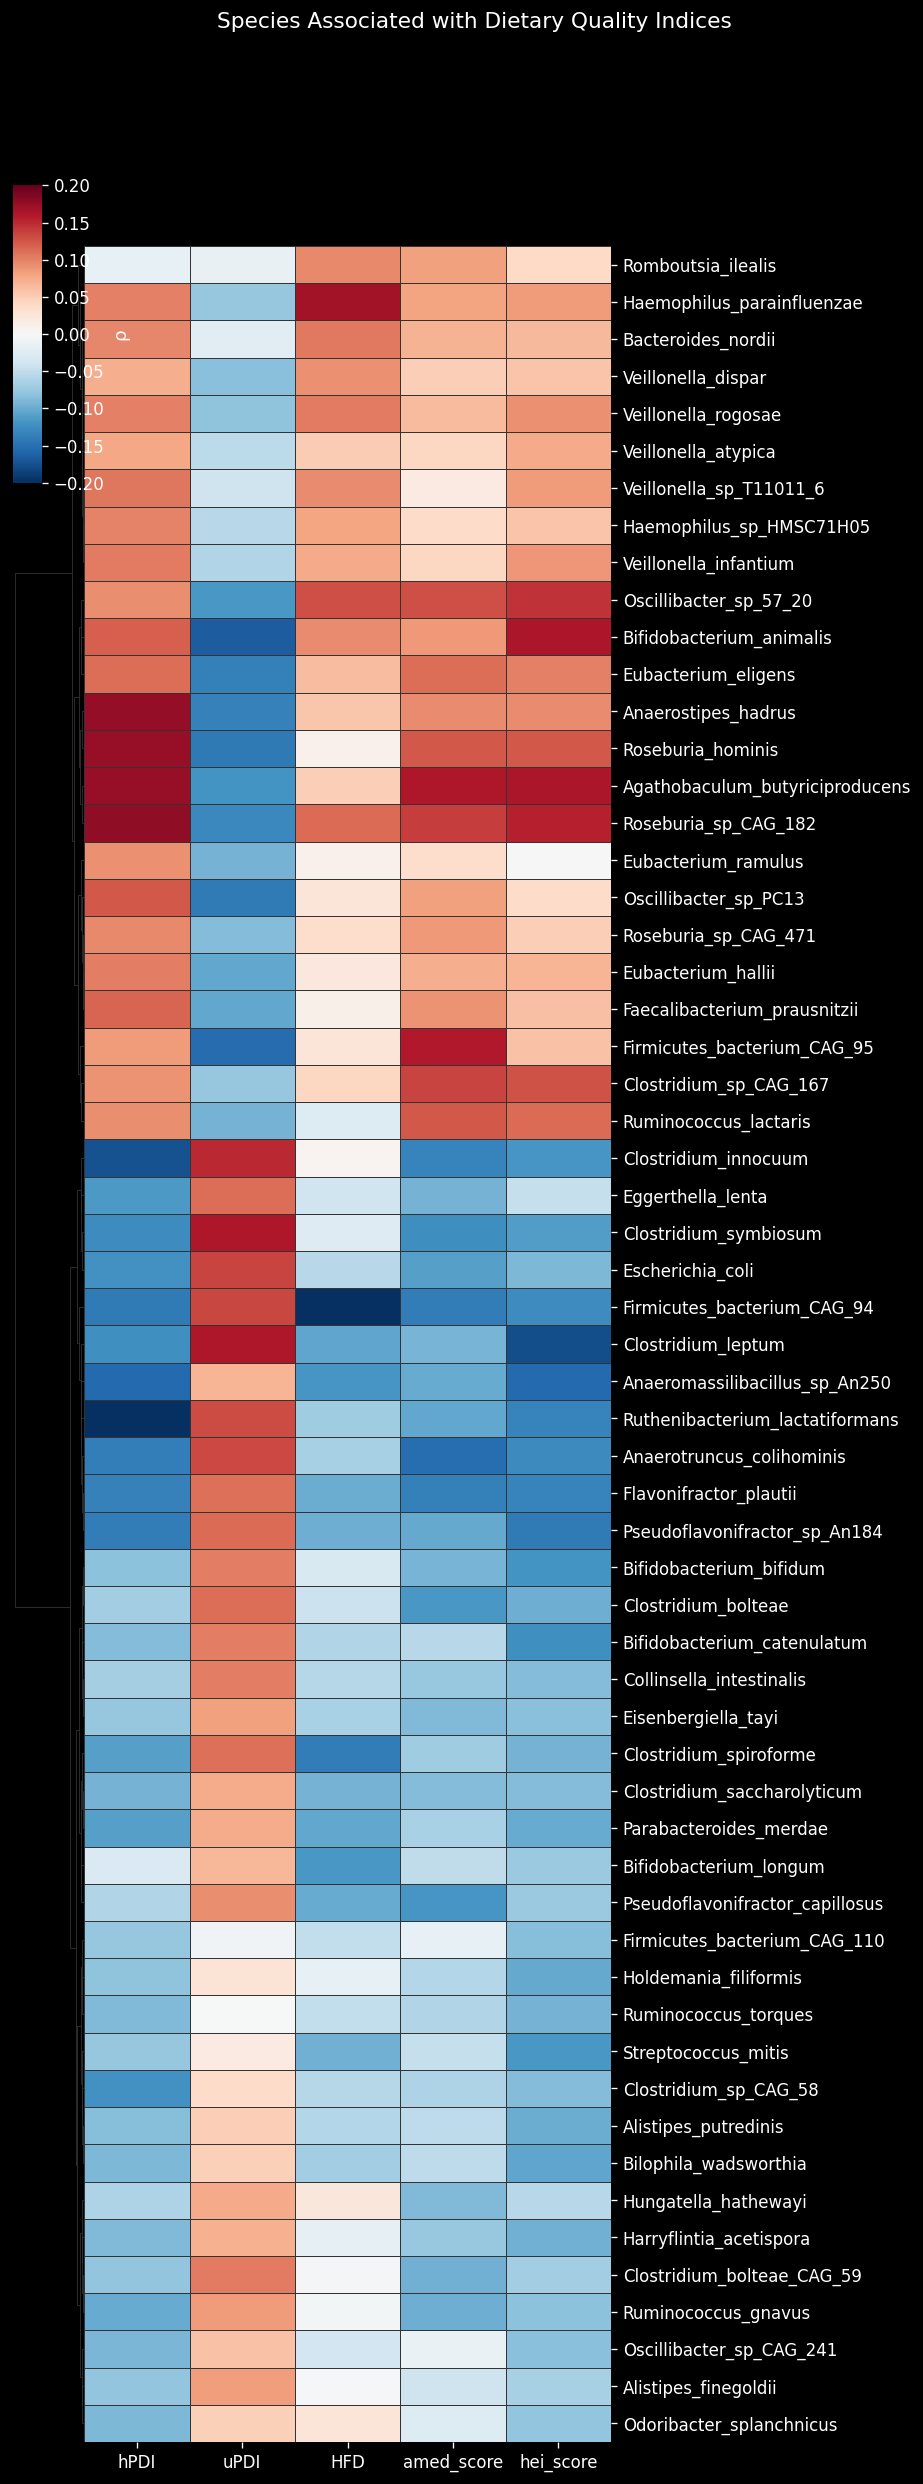

In [8]:
pattern_matrix = pattern_df.pivot(index='species', columns='variable', values='spearman_r')
pattern_q = pattern_df.pivot(index='species', columns='variable', values='qvalue')

key_indices = ['hPDI', 'uPDI', 'HFD', 'amed_score', 'hei_score']
available = [k for k in key_indices if k in pattern_matrix.columns]

idx_sig = (pattern_q[available] < 0.2).sum(axis=1)
responsive = idx_sig[idx_sig >= 2].index.tolist()
print(f'Species responding to ≥2 dietary indices: {len(responsive)}')

sub = pattern_matrix.loc[responsive, available]

g = sns.clustermap(
    sub,
    cmap='RdBu_r', center=0, vmin=-0.2, vmax=0.2,
    linewidths=0.3, linecolor='#333333',
    figsize=(8, max(8, len(responsive) * 0.35)),
    dendrogram_ratio=(0.12, 0.08),
    cbar_pos=(0.02, 0.82, 0.03, 0.12),
    cbar_kws={'label': 'ρ'},
    method='ward',
    col_cluster=False,
)
g.ax_heatmap.set_xlabel('')
g.ax_heatmap.set_ylabel('')
g.fig.suptitle('Species Associated with Dietary Quality Indices', y=1.01, fontsize=13)
plt.show()

## 7. Nutrient-Level Associations

The nutrient sheet gives higher resolution than food groups. Here we look at fiber, fat subtypes, and key micronutrients.

Key nutrient columns found: ['Carbohydrate_sugars_total_kcal', 'Cholesterol_kcal', 'Englyst_Fibre_Non_Starch_Polysaccharides_NSP_kcal', 'Fat_total_kcal', 'Monounsaturated_fatty_acids_MUFA_total_kcal', 'Polyunsaturated_fatty_acids_PUFA_total_kcal', 'Protein_kcal', 'Saturated_fatty_acids_SFA_total_kcal']
Species with ≥2 significant nutrient associations: 57


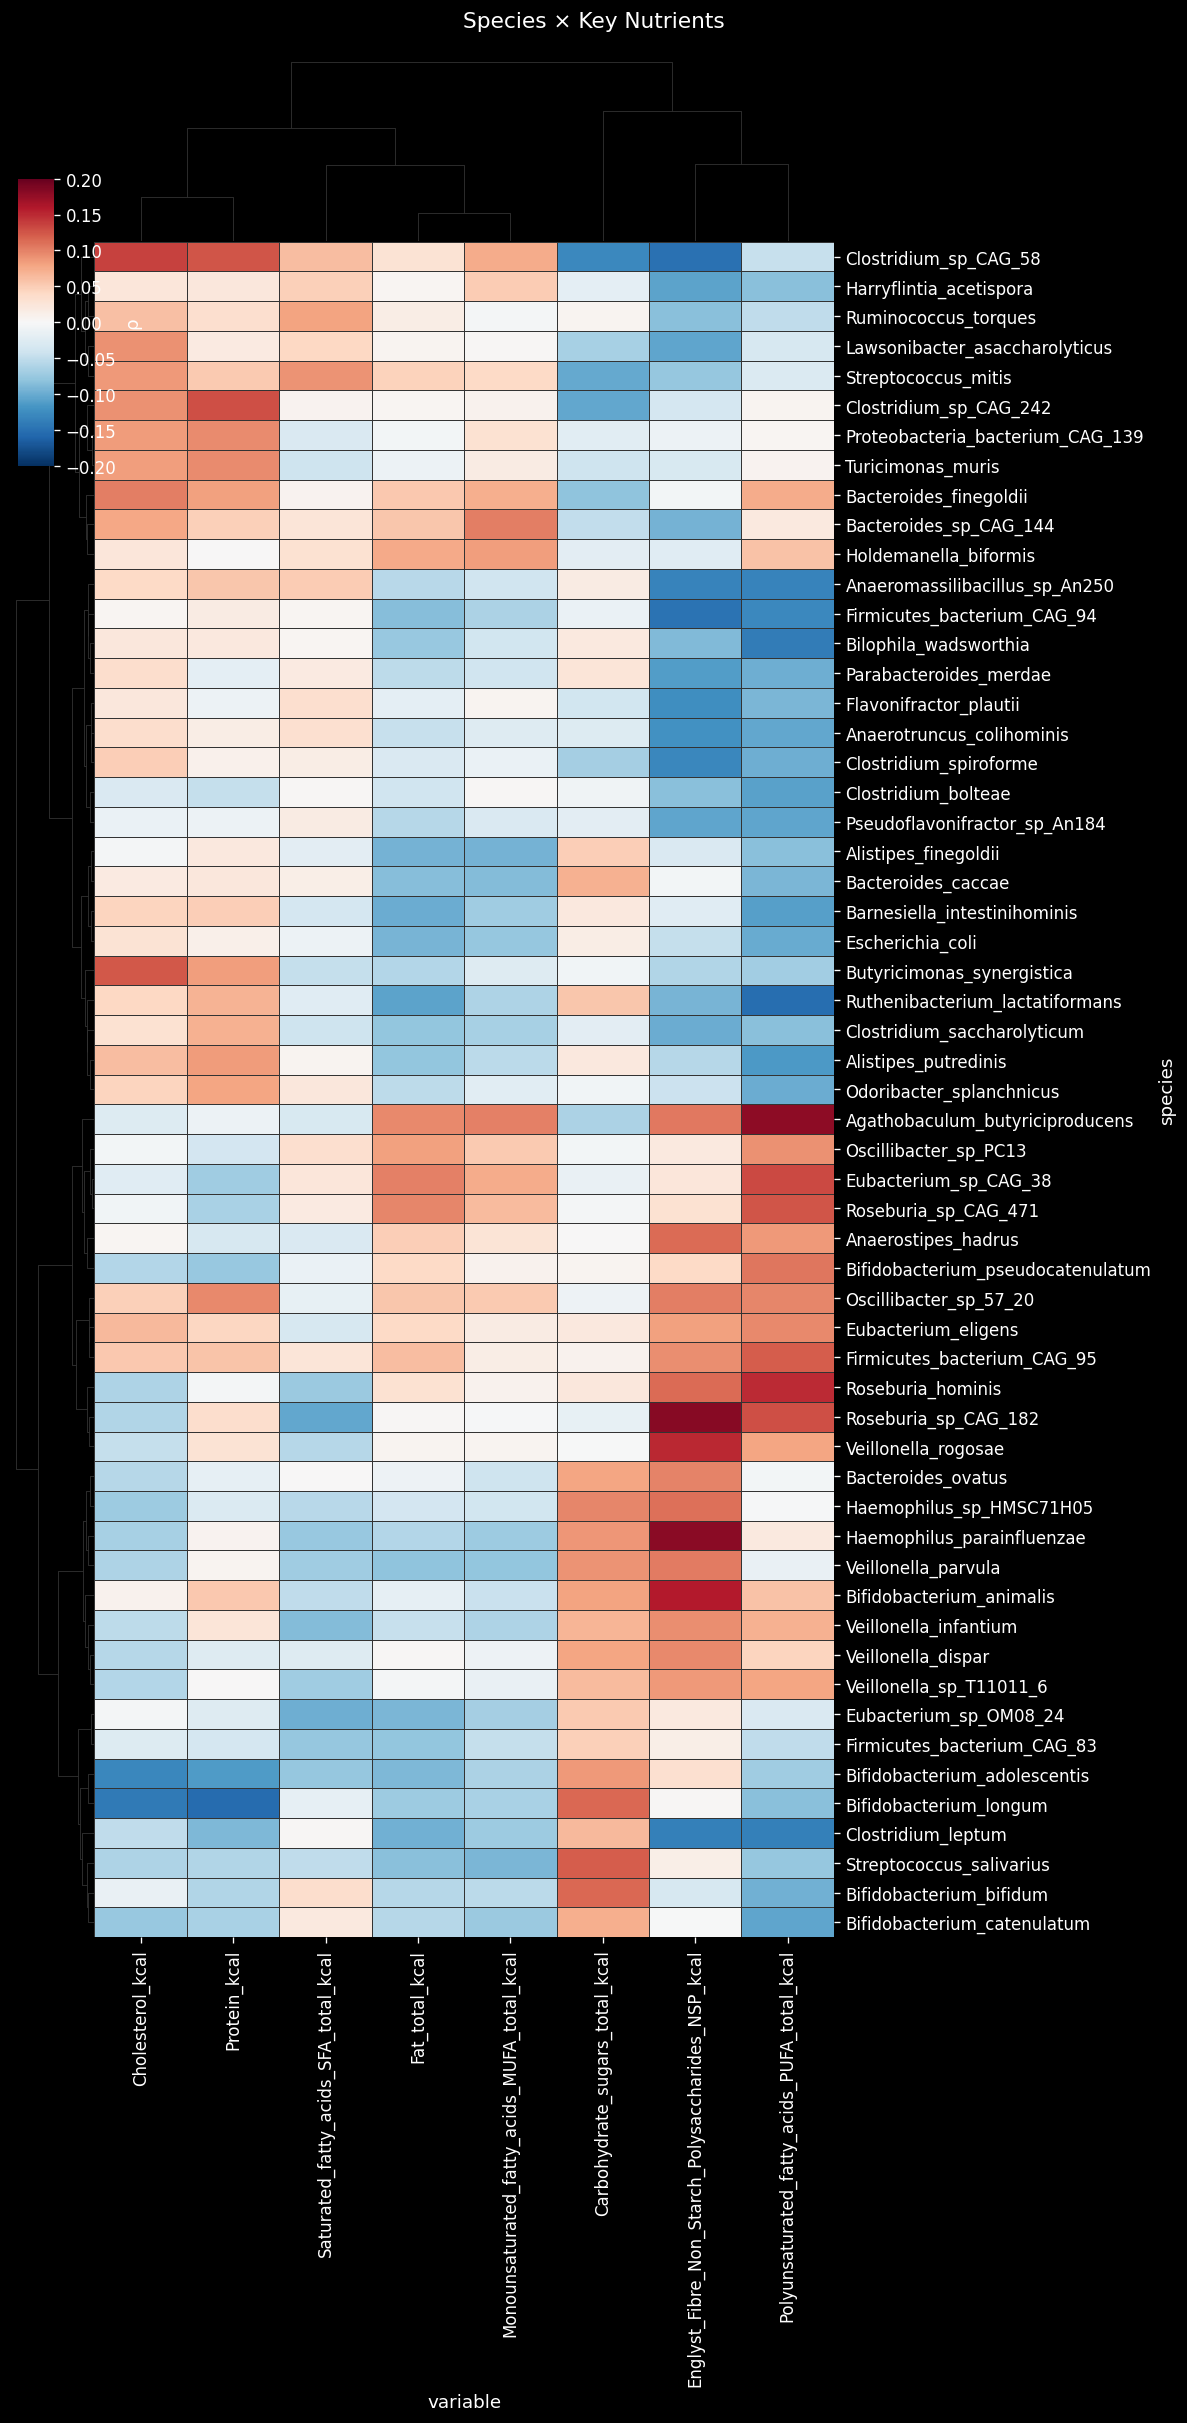

In [9]:
nutrient_matrix = nutrient_df.pivot(index='species', columns='variable', values='spearman_r')
nutrient_q = nutrient_df.pivot(index='species', columns='variable', values='qvalue')

key_nutrients = [
    col for col in nutrient_matrix.columns
    if any(kw in col.lower() for kw in ['fibre', 'fiber', 'fat_total', 'saturated', 'polyunsaturated', 'sugar', 'protein', 'cholesterol'])
]
print('Key nutrient columns found:', key_nutrients)

if key_nutrients:
    n_sub = nutrient_matrix[key_nutrients]
    n_sig = (nutrient_q[key_nutrients] < 0.2).sum(axis=1)
    responsive_n = n_sig[n_sig >= 2].index.tolist()
    print(f'Species with ≥2 significant nutrient associations: {len(responsive_n)}')

    if responsive_n:
        g = sns.clustermap(
            n_sub.loc[responsive_n],
            cmap='RdBu_r', center=0, vmin=-0.2, vmax=0.2,
            linewidths=0.3, linecolor='#333333',
            figsize=(10, max(8, len(responsive_n) * 0.35)),
            dendrogram_ratio=(0.1, 0.1),
            cbar_pos=(0.02, 0.82, 0.03, 0.12),
            cbar_kws={'label': 'ρ'},
            method='ward',
        )
        g.fig.suptitle('Species × Key Nutrients', y=1.01, fontsize=13)
        plt.show()

## 8. "Healthy" vs "Unhealthy" Microbe Profiles (Table 9)

Supplementary Table 9 ranks all 176 species by their average correlation across health-positive and health-negative markers. This gives us a single "health axis" for each species.

In [10]:
t9_wb = SUPP_DIR / '41591_2020_1183_MOESM10_ESM.xlsx'
t9 = pd.read_excel(t9_wb, sheet_name='Ranks', skiprows=3, engine='openpyxl')
t9.columns = ['species'] + list(t9.columns[1:])
t9 = t9[t9['species'].notna() & (t9['species'] != 'Category')]
t9 = t9.reset_index(drop=True)

t9['Final Rank'] = pd.to_numeric(t9['Final Rank'], errors='coerce')
t9 = t9.dropna(subset=['Final Rank'])
t9 = t9.sort_values('Final Rank')

print(f'Table 9: {len(t9)} species with health rankings')
print(f'\nTop 10 "healthiest" species (lowest rank):')
print(t9[['species', 'Final Rank']].head(10).to_string(index=False))
print(f'\nTop 10 "least healthy" species (highest rank):')
print(t9[['species', 'Final Rank']].tail(10).to_string(index=False))


Table 9: 176 species with health rankings

Top 10 "healthiest" species (lowest rank):
                     species  Final Rank
 Firmicutes_bacterium_CAG_95    9.670833
  Haemophilus_parainfluenzae   10.091667
      Oscillibacter_sp_57_20   12.191667
Firmicutes_bacterium_CAG_170   13.966667
        Roseburia_sp_CAG_182   14.641667
      Clostridium_sp_CAG_167   19.970833
       Oscillibacter_sp_PC13   20.466667
         Eubacterium_eligens   20.875000
            Prevotella_copri   24.437500
          Veillonella_dispar   25.037500

Top 10 "least healthy" species (highest rank):
                   species  Final Rank
     Clostridium_sp_CAG_58  154.358333
         Eggerthella_lenta  154.570833
       Ruminococcus_gnavus  159.750000
    Clostridium_spiroforme  160.258333
Clostridium_bolteae_CAG_59  160.970833
      Clostridium_innocuum  163.562500
 Anaerotruncus_colihominis  164.912500
     Clostridium_symbiosum  165.795833
       Clostridium_bolteae  166.954167
    Flavonifractor_plauti

## 9. Food Group Profiles: Which Microbes Does Each Food Promote/Suppress?

A practical view for the 86BB installation: for each food group, show the top species it promotes and suppresses.

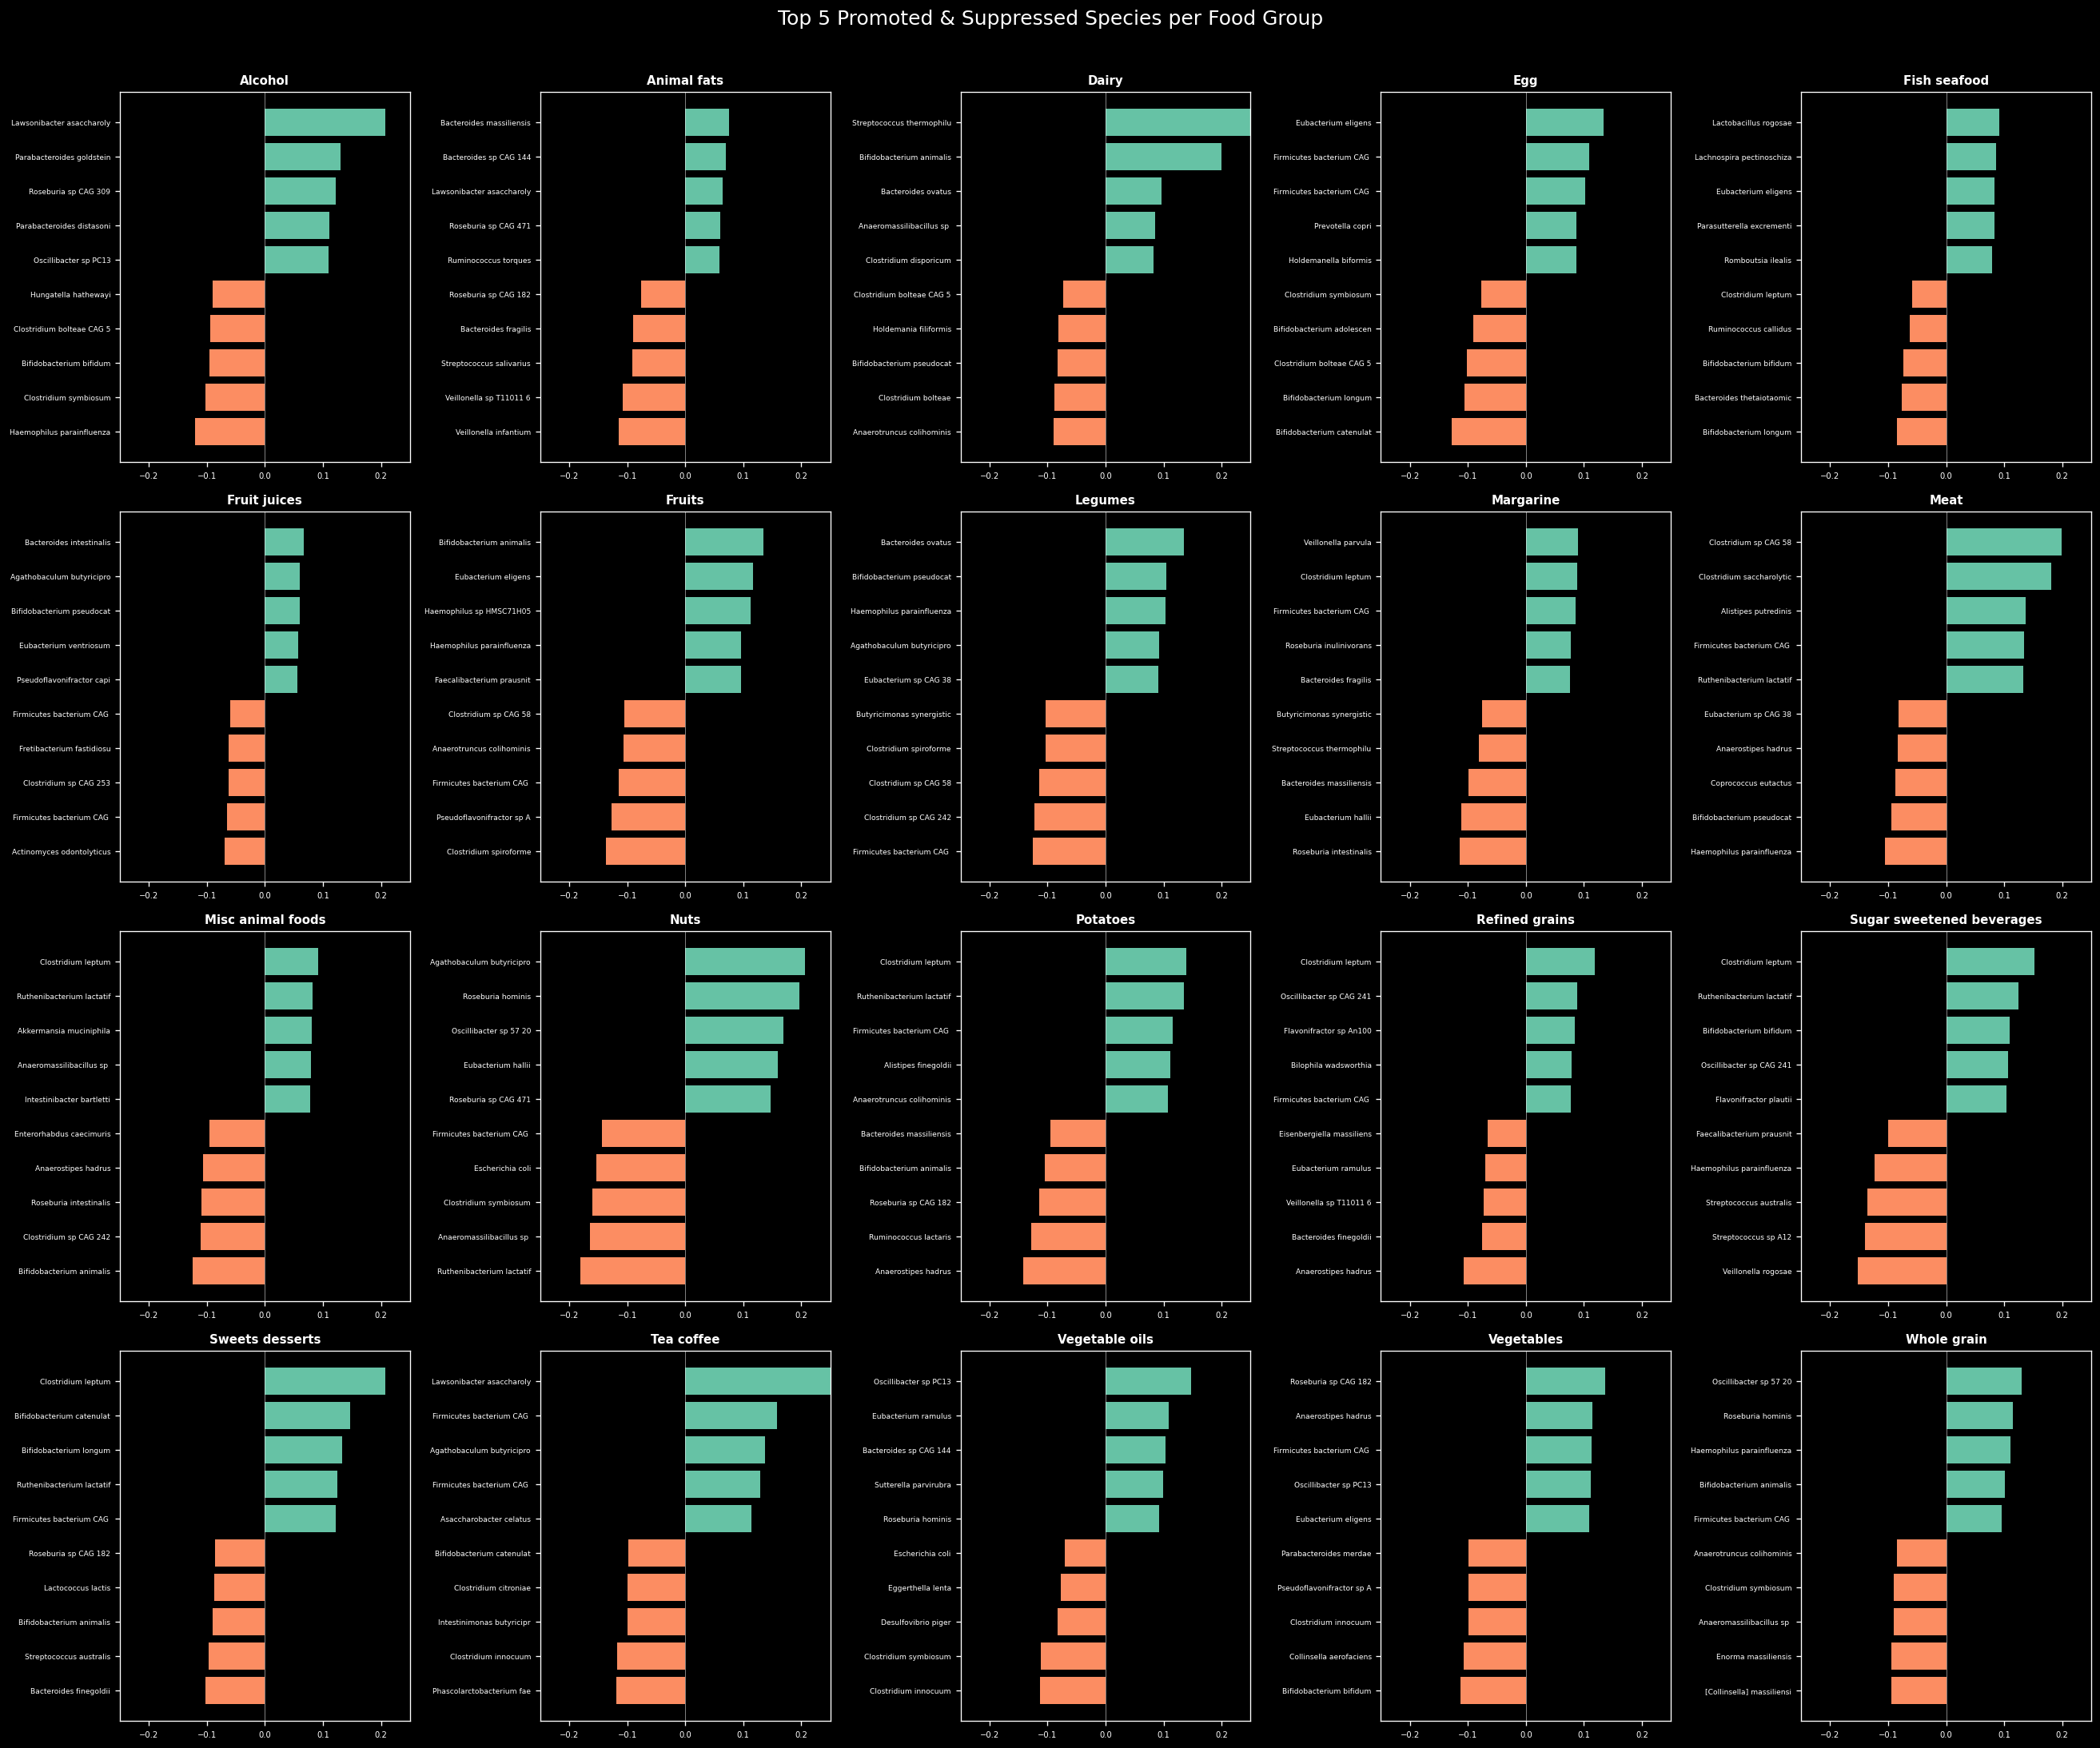

In [11]:
food_groups = sorted(food_df['variable'].unique())
n_groups = len(food_groups)

fig, axes = plt.subplots(4, 5, figsize=(22, 18))
axes = axes.flatten()

for i, fg in enumerate(food_groups):
    ax = axes[i]
    sub = food_df[food_df['variable'] == fg].copy()
    sub = sub.sort_values('spearman_r')
    
    top_neg = sub.head(5)
    top_pos = sub.tail(5)
    show = pd.concat([top_neg, top_pos])
    
    colors = ['#FC8D62' if r < 0 else '#66C2A5' for r in show['spearman_r']]
    labels = [s.replace('_', ' ')[:25] for s in show['species']]
    
    ax.barh(range(len(show)), show['spearman_r'], color=colors, edgecolor='none')
    ax.set_yticks(range(len(show)))
    ax.set_yticklabels(labels, fontsize=5.5)
    ax.set_title(fg.replace('_', ' '), fontsize=9, fontweight='bold')
    ax.axvline(0, color='white', linewidth=0.3)
    ax.set_xlim(-0.25, 0.25)
    ax.tick_params(axis='x', labelsize=6)

fig.suptitle('Top 5 Promoted & Suppressed Species per Food Group', fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

## 10. Correlation Distribution: How Strong Are These Associations?

Most food–microbe correlations are modest (|ρ| < 0.1). This is normal for observational microbiome studies — the gut is shaped by hundreds of factors. But statistically significant associations at ρ = 0.1–0.25 are still biologically meaningful, especially when replicated across cohorts (which the paper does with a US validation set).

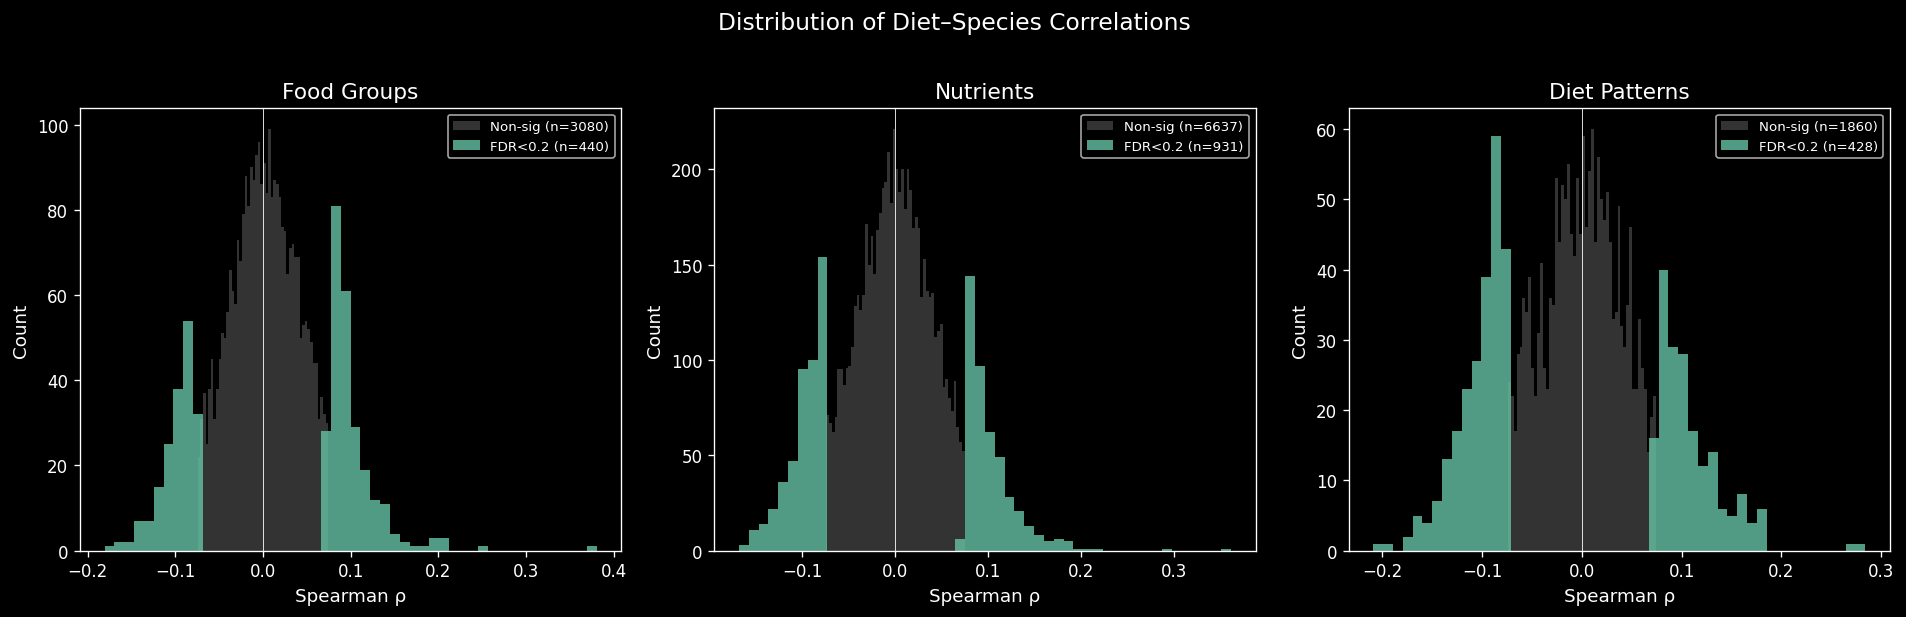

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (name, df) in zip(axes, [('Food Groups', food_df), ('Nutrients', nutrient_df), ('Diet Patterns', pattern_df)]):
    sig_r = df[df['qvalue'] < 0.2]['spearman_r']
    nonsig_r = df[df['qvalue'] >= 0.2]['spearman_r']
    
    ax.hist(nonsig_r, bins=50, alpha=0.5, label=f'Non-sig (n={len(nonsig_r)})', color='#666666')
    ax.hist(sig_r, bins=50, alpha=0.8, label=f'FDR<0.2 (n={len(sig_r)})', color='#66C2A5')
    ax.axvline(0, color='white', linewidth=0.5)
    ax.set_xlabel('Spearman ρ')
    ax.set_ylabel('Count')
    ax.set_title(name)
    ax.legend(fontsize=8)

fig.suptitle('Distribution of Diet–Species Correlations', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 11. Summary Statistics

In [13]:
print('=== PREDICT 1 Diet-Microbiome Data Summary ===')
print(f'Species profiled: {food_df.species.nunique()}')
print(f'Food groups: {food_df.variable.nunique()}')
print(f'Nutrients (energy-adjusted): {nutrient_df.variable.nunique()}')
print(f'Dietary pattern indices: {pattern_df.variable.nunique()}')
print()
print(f'Significant food-species associations (FDR < 0.2): {(food_df.qvalue < 0.2).sum()}')
print(f'Significant food-species associations (FDR < 0.05): {(food_df.qvalue < 0.05).sum()}')
print(f'Strongest positive: {food_df.loc[food_df.spearman_r.idxmax()][["variable","species","spearman_r"]].to_dict()}')
print(f'Strongest negative: {food_df.loc[food_df.spearman_r.idxmin()][["variable","species","spearman_r"]].to_dict()}')
print()
print('Top genera represented:')
genera = food_df['species'].str.split('_').str[0].value_counts()
print(genera.head(15).to_string())

=== PREDICT 1 Diet-Microbiome Data Summary ===
Species profiled: 176
Food groups: 20
Nutrients (energy-adjusted): 43
Dietary pattern indices: 13

Significant food-species associations (FDR < 0.2): 440
Significant food-species associations (FDR < 0.05): 142
Strongest positive: {'variable': 'Tea_coffee', 'species': 'Lawsonibacter_asaccharolyticus', 'spearman_r': 0.380371431514554}
Strongest negative: {'variable': 'Nuts', 'species': 'Ruthenibacterium_lactatiformans', 'spearman_r': -0.18057509535161}

Top genera represented:
species
Bacteroides        420
Clostridium        300
Eubacterium        220
Firmicutes         140
Roseburia          140
Alistipes          120
Bifidobacterium    120
Ruminococcus       120
Streptococcus      120
Veillonella        120
Parabacteroides     80
Blautia             60
Collinsella         60
Coprococcus         60
Oscillibacter       60


## 12. Export: Food Group × Species Correlation Matrix

Save the pivoted matrix as CSV for downstream use.

In [14]:
out_dir = Path('../../analysis/outputs')
out_dir.mkdir(parents=True, exist_ok=True)

food_matrix.to_csv(out_dir / 'predict1_food_species_correlations.csv')
food_q_matrix.to_csv(out_dir / 'predict1_food_species_qvalues.csv')

sig_only = food_df[food_df['qvalue'] < 0.2][['variable', 'species', 'spearman_r', 'qvalue']]
sig_only.to_csv(out_dir / 'predict1_significant_food_species.csv', index=False)

print(f'Exported {food_matrix.shape[0]}×{food_matrix.shape[1]} correlation matrix')
print(f'Exported {len(sig_only)} significant associations')
print(f'Files saved to {out_dir.resolve()}')

Exported 176×20 correlation matrix
Exported 440 significant associations
Files saved to /Users/ryanmillett/86BB/analysis/outputs
